# Machine Unlearning — Evaluation

Compares three unlearning techniques (Gradient Ascent, Gradient Difference, Random Labels) on two Qwen models using existing CSV grid-search results.

**Metrics:**
- `forgetting_rate` = `(efficacy_before - efficacy_after) / efficacy_before` — fraction of target knowledge removed (1.0 = complete forgetting)
- `retention_rate` = `retain_after / retain_before` — fraction of general/neighbour knowledge preserved (1.0 = no collateral damage)
- `harmonic_mean` = `2 * forgetting_rate * retention_rate / (forgetting_rate + retention_rate)` — combined metric equivalent to F1-score;

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal, mannwhitneyu
from itertools import combinations

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120

## 1. Load and Unify CSVs

In [2]:
files = {
    'GA': {
        'Qwen2.5-3B': 'gradient_ascent/ga_unlearning_grid_results_Qwen2.5-3B.csv',
        'Qwen3-4B':   'gradient_ascent/ga_unlearning_grid_results_Qwen3-4B.csv',
    },
    'GD': {
        'Qwen2.5-3B': 'gradient_difference/unlearning_grid_results_Qwen2.5-3B.csv',
         'Qwen3-4B': 'gradient_difference/unlearning_grid_results_Qwen3-4B.csv',  # add later
    },
    'RL': {
        'Qwen2.5-3B': 'random_labels/unlearning_grid_results_Qwen2.5-3B.csv',
        'Qwen3-4B':   'random_labels/unlearning_grid_results_Qwen3-4B.csv',
    },
}

dfs = []
for technique, models in files.items():
    for model_name, path in models.items():
        df = pd.read_csv(path)
        df['technique'] = technique
        df['model_name'] = model_name
        # GA and RL use neighbours_before/after; GD uses retain_before/after — normalise
        if 'neighbours_before' in df.columns:
            df = df.rename(columns={
                'neighbours_before': 'retain_before',
                'neighbours_after':  'retain_after'
            })
        dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
print(f"Loaded {len(data)} rows across {data['technique'].nunique()} techniques and {data['model_name'].nunique()} models.")
data.head()

Loaded 54 rows across 3 techniques and 2 models.


,model,subject,lr,max_steps,efficacy_before,efficacy_after,retain_before,retain_after,technique,model_name,retain_loss_weight,beta
0,Qwen/Qwen2.5-3B-Instruct,Donald Trump,0.00010,30.0,85.0,85.0,63.3,60.0,GA,Qwen2.5-3B,NaN,NaN
1,Qwen/Qwen2.5-3B-Instruct,Donald Trump,0.00010,100.0,85.0,0.0,63.3,0.0,GA,Qwen2.5-3B,NaN,NaN
2,Qwen/Qwen2.5-3B-Instruct,Donald Trump,0.00010,300.0,85.0,0.0,63.3,0.0,GA,Qwen2.5-3B,NaN,NaN
3,Qwen/Qwen2.5-3B-Instruct,Donald Trump,0.00003,30.0,85.0,0.0,63.3,0.0,GA,Qwen2.5-3B,NaN,NaN
4,Qwen/Qwen2.5-3B-Instruct,Donald Trump,0.00003,100.0,85.0,0.0,63.3,0.0,GA,Qwen2.5-3B,NaN,NaN


## 2. Calculating forgetting rate and retention rate

In [3]:
data['forgetting_rate'] = (data['efficacy_before'] - data['efficacy_after']) / data['efficacy_before']
data['retention_rate']  = data['retain_after'] / data['retain_before']

# Clamp to [0, 1] to handle floating-point noise
data['forgetting_rate'] = data['forgetting_rate'].clip(0, 1)
data['retention_rate']  = data['retention_rate'].clip(0, 1)

# Harmonic mean; defined as 0 when both rates are 0
denom = data['forgetting_rate'] + data['retention_rate']
data['harmonic_mean'] = np.where(
    denom > 0,
    2 * data['forgetting_rate'] * data['retention_rate'] / denom,
    0.0
)

data[['technique', 'model_name', 'forgetting_rate', 'retention_rate', 'harmonic_mean']].head(20)

,technique,model_name,forgetting_rate,retention_rate,harmonic_mean
0,GA,Qwen2.5-3B,0.000000,0.947867,0.000000
1,GA,Qwen2.5-3B,1.000000,0.000000,0.000000
2,GA,Qwen2.5-3B,1.000000,0.000000,0.000000
3,GA,Qwen2.5-3B,1.000000,0.000000,0.000000
4,GA,Qwen2.5-3B,1.000000,0.000000,0.000000
5,GA,Qwen2.5-3B,1.000000,0.000000,0.000000
6,GA,Qwen2.5-3B,1.000000,0.000000,0.000000
7,GA,Qwen2.5-3B,1.000000,0.000000,0.000000
8,GA,Qwen2.5-3B,1.000000,0.000000,0.000000
9,GA,Qwen3-4B,0.105263,1.000000,0.190476


## 3. Best Configuration per Technique and Model

Selects the row with the highest `harmonic_mean` — this balances forgetting and retention so configurations that destroy the model (forgetting=1, retention=0) do not get selected.

In [4]:
best = data.loc[
    data.groupby(['technique', 'model_name'])['harmonic_mean'].idxmax()
].reset_index(drop=True)

best[['technique', 'model_name', 'forgetting_rate', 'retention_rate', 'harmonic_mean']].round(3)

,technique,model_name,forgetting_rate,retention_rate,harmonic_mean
0,GA,Qwen2.5-3B,0.000,0.948,0.000
1,GA,Qwen3-4B,0.105,1.000,0.190
2,GD,Qwen2.5-3B,0.412,0.579,0.481
3,GD,Qwen3-4B,0.526,0.450,0.485
4,RL,Qwen2.5-3B,0.750,0.286,0.414
5,RL,Qwen3-4B,1.000,0.471,0.640


## 4. Heatmaps — Hyperparameter Sensitivity

Each pair of heatmaps shows `forgetting_rate` and `retention_rate` across the grid for one technique × model.
Green = high (good), red = low (poor).

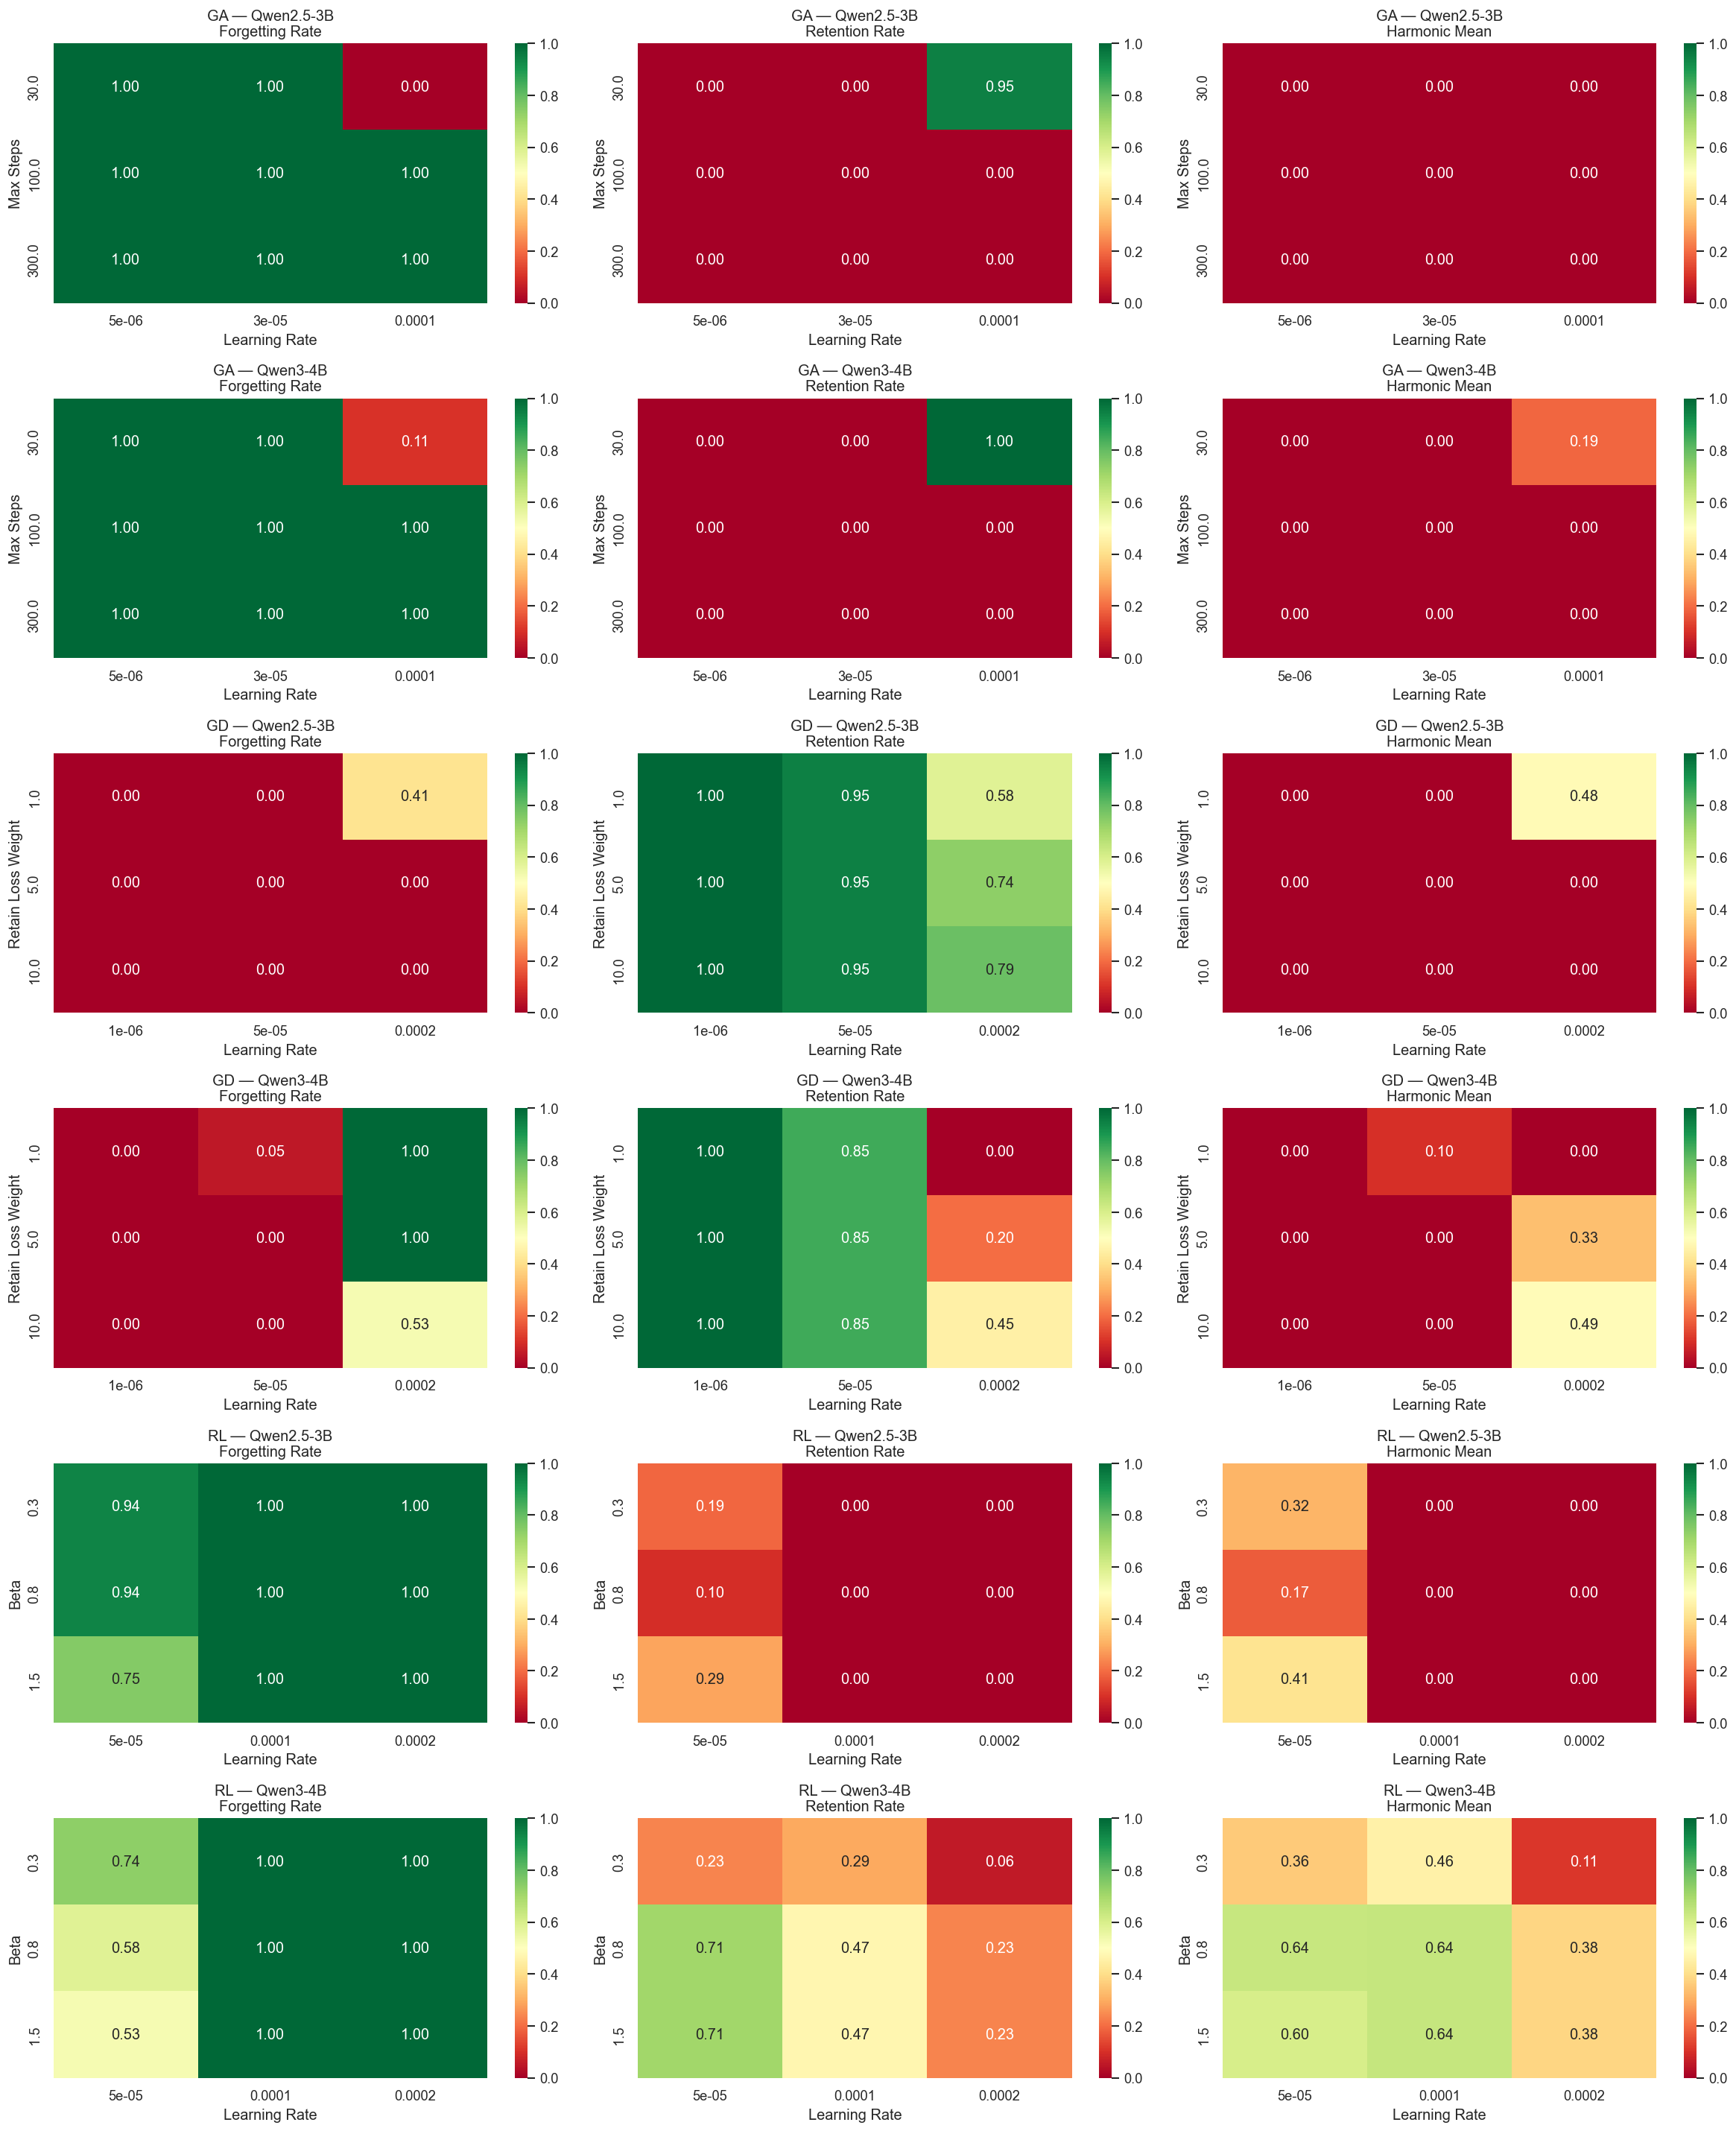

In [5]:
PARAM2 = {'GA': 'max_steps', 'GD': 'retain_loss_weight', 'RL': 'beta'}
LABEL2 = {'GA': 'Max Steps', 'GD': 'Retain Loss Weight', 'RL': 'Beta'}

combos = data[['technique', 'model_name']].drop_duplicates().values.tolist()
ncols = 3
nrows = len(combos)
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows))

if nrows == 1:
    axes = [axes]

metric_pairs = [
    ('forgetting_rate', 'Forgetting Rate'),
    ('retention_rate',  'Retention Rate'),
    ('harmonic_mean',   'Harmonic Mean'),
]

for row_idx, (technique, model_name) in enumerate(combos):
    subset = data[(data['technique'] == technique) & (data['model_name'] == model_name)]
    p2 = PARAM2[technique]
    for col_idx, (metric, metric_label) in enumerate(metric_pairs):
        ax = axes[row_idx][col_idx]
        try:
            pivot = subset.pivot(index=p2, columns='lr', values=metric)
            sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn',
                        vmin=0, vmax=1, ax=ax, cbar=True)
            ax.set_title(f'{technique} — {model_name}\n{metric_label}')
            ax.set_ylabel(LABEL2[technique])
            ax.set_xlabel('Learning Rate')
        except Exception as e:
            ax.text(0.5, 0.5, str(e), ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{technique} — {model_name} ({metric_label})')

plt.tight_layout()
plt.savefig('evaluation_heatmaps.png', bbox_inches='tight')
plt.show()

## 5. Scatter: Forgetting vs. Retention Trade-off

Each point is one hyperparameter configuration. The ideal region is top-right (high forgetting, high retention).

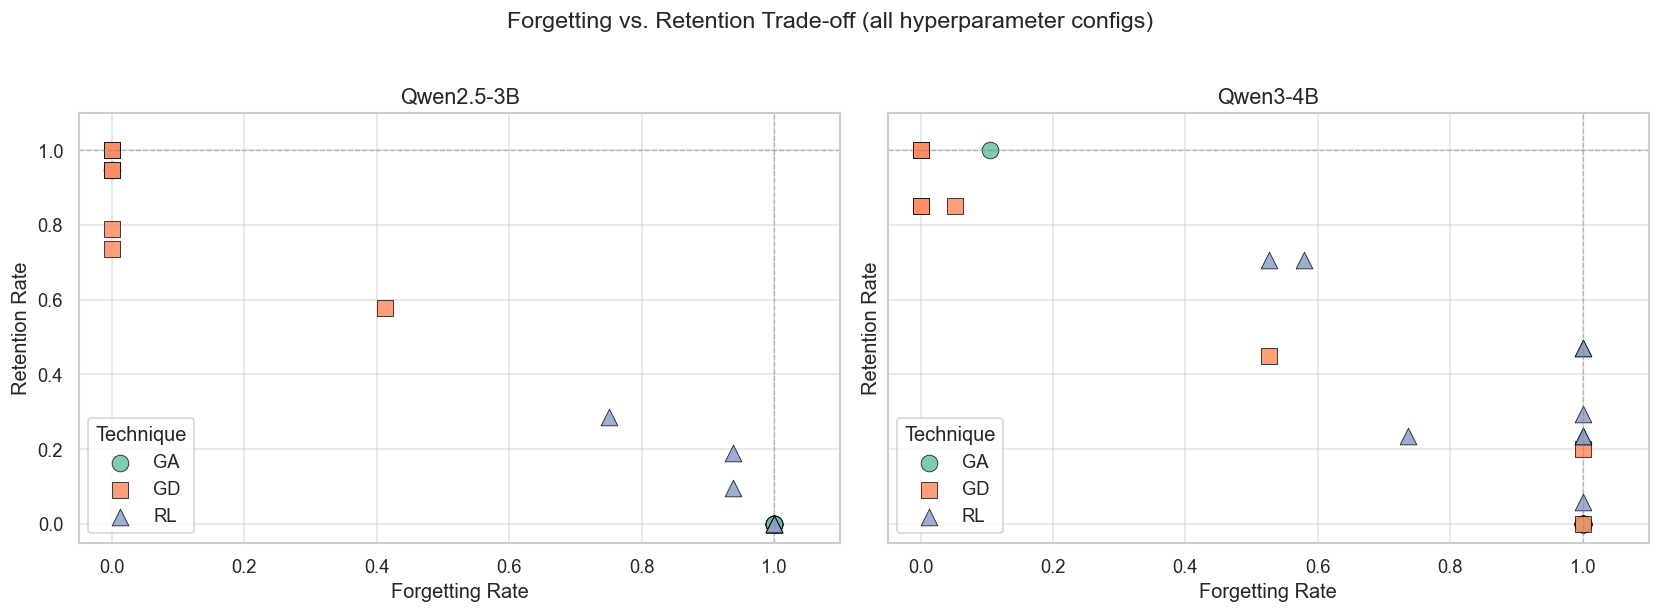

In [6]:
models_available = sorted(data['model_name'].unique())
techniques = sorted(data['technique'].unique())
colors = dict(zip(techniques, sns.color_palette('Set2', len(techniques))))
markers = {'GA': 'o', 'GD': 's', 'RL': '^'}

fig, axes = plt.subplots(1, len(models_available), figsize=(7 * len(models_available), 5), sharey=True)
if len(models_available) == 1:
    axes = [axes]

for ax, model_name in zip(axes, models_available):
    subset = data[data['model_name'] == model_name]
    for tech, grp in subset.groupby('technique'):
        ax.scatter(
            grp['forgetting_rate'], grp['retention_rate'],
            label=tech, color=colors[tech], marker=markers.get(tech, 'o'),
            s=100, edgecolors='black', linewidths=0.5, alpha=0.85
        )
    ax.axhline(1.0, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axvline(1.0, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_xlim(-0.05, 1.1)
    ax.set_ylim(-0.05, 1.1)
    ax.set_xlabel('Forgetting Rate', fontsize=12)
    ax.set_ylabel('Retention Rate', fontsize=12)
    ax.set_title(model_name, fontsize=13)
    ax.legend(title='Technique')

fig.suptitle('Forgetting vs. Retention Trade-off (all hyperparameter configs)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('evaluation_scatter.png', bbox_inches='tight')
plt.show()

## 6. Bar Chart — Best Forgetting and Retention per Technique

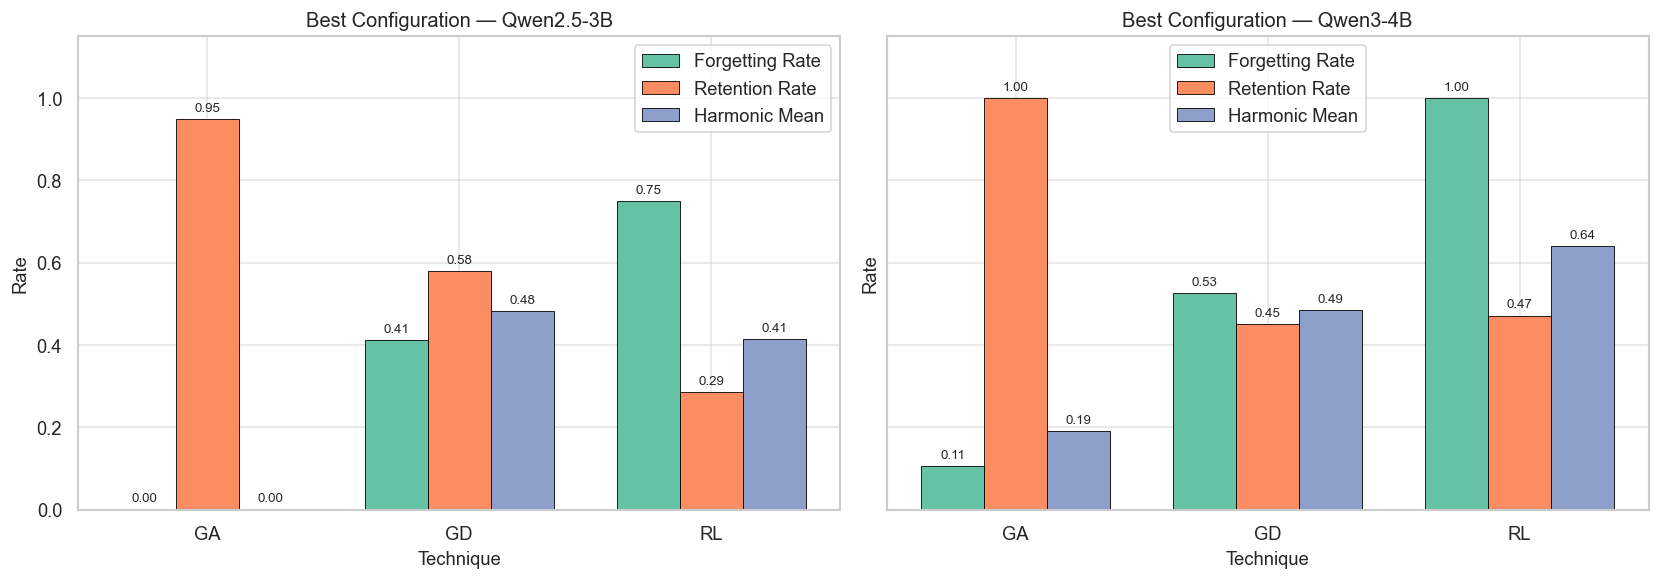

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
models_available = sorted(best['model_name'].unique())
palette = sns.color_palette('Set2', 3)

for ax, model_name in zip(axes, models_available):
    subset = best[best['model_name'] == model_name].set_index('technique')
    x = np.arange(len(subset))
    width = 0.25
    bars1 = ax.bar(x - width, subset['forgetting_rate'], width, label='Forgetting Rate',
                   color=palette[0], edgecolor='black', linewidth=0.5)
    bars2 = ax.bar(x,          subset['retention_rate'],  width, label='Retention Rate',
                   color=palette[1], edgecolor='black', linewidth=0.5)
    bars3 = ax.bar(x + width,  subset['harmonic_mean'],   width, label='Harmonic Mean',
                   color=palette[2], edgecolor='black', linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(subset.index)
    ax.set_ylim(0, 1.15)
    ax.set_xlabel('Technique', fontsize=11)
    ax.set_ylabel('Rate', fontsize=11)
    ax.set_title(f'Best Configuration — {model_name}', fontsize=12)
    ax.legend()
    for bars in [bars1, bars2, bars3]:
        ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=8)

plt.tight_layout()
plt.savefig('evaluation_best_scores.png', bbox_inches='tight')
plt.show()

## 7. Statistical Tests - What model is the best?

Takes results from all of the parmeters config

Tests are run separately for `forgetting_rate` and `retention_rate`.

**What these tests answer:** Does one technique tend to produce systematically higher/lower forgetting or retention *across its hyperparameter search space* than another?

**Tests used:**
- **Kruskal-Wallis**
- **Mann-Whitney U**
- **Rank-biserial r**

In [8]:
BONFERRONI_ALPHA = 0.05 / 3

for metric in ['forgetting_rate', 'retention_rate', 'harmonic_mean']:
    print(f"\n{'='*60}")
    print(f"  METRIC: {metric.upper()}")
    print(f"{'='*60}")

    for model_name in sorted(data['model_name'].unique()):
        subset = data[data['model_name'] == model_name]
        groups = {t: g[metric].values for t, g in subset.groupby('technique')}

        if len(groups) < 2:
            continue

        print(f"\n  Model: {model_name}")

        # --- Kruskal-Wallis ---
        stat, p_kw = kruskal(*groups.values())
        print(f"\n  [Kruskal-Wallis] Overall test across all techniques")
        print(f"  H = {stat:.3f},  p = {p_kw:.4f}{'  * significant at α=0.05' if p_kw < 0.05 else '  (not significant)'}")

        # --- Mann-Whitney U (pairwise) ---
        print(f"\n  [Mann-Whitney U] Pairwise comparisons (Bonferroni-corrected α = {BONFERRONI_ALPHA:.4f})")
        print(f"  {'Comparison':<16} {'U statistic':>12} {'p-value':>10} {'Significant':>13} {'Effect r':>10}")
        print(f"  {'─'*65}")

        for (n1, g1), (n2, g2) in combinations(groups.items(), 2):
            u, p_mw = mannwhitneyu(g1, g2, alternative='two-sided')
            r = 1 - 2 * u / (len(g1) * len(g2))
            sig = 'YES *' if p_mw < BONFERRONI_ALPHA else 'no'
            print(f"  {n1} vs {n2:<10} {u:>12.1f} {p_mw:>10.4f} {sig:>13} {r:>10.3f}")


  METRIC: FORGETTING_RATE

  Model: Qwen2.5-3B

  [Kruskal-Wallis] Overall test across all techniques
  H = 18.647,  p = 0.0001  * significant at α=0.05

  [Mann-Whitney U] Pairwise comparisons (Bonferroni-corrected α = 0.0167)
  Comparison        U statistic    p-value   Significant   Effect r
  ─────────────────────────────────────────────────────────────────
  GA vs GD                 76.0     0.0005         YES *     -0.877
  GA vs RL                 48.0     0.3956            no     -0.185
  GD vs RL                  0.0     0.0002         YES *      1.000

  Model: Qwen3-4B

  [Kruskal-Wallis] Overall test across all techniques
  H = 11.433,  p = 0.0033  * significant at α=0.05

  [Mann-Whitney U] Pairwise comparisons (Bonferroni-corrected α = 0.0167)
  Comparison        U statistic    p-value   Significant   Effect r
  ─────────────────────────────────────────────────────────────────
  GA vs GD                 70.0     0.0044         YES *     -0.728
  GA vs RL                 

## 8. Descriptive Statistics per Technique × Model

In [9]:
desc = (
    data.groupby(['technique', 'model_name'])[['forgetting_rate', 'retention_rate', 'harmonic_mean']]
    .agg(['mean', 'std', 'min', 'max'])
    .round(3)
)
desc

forgetting_rate                      retention_rate  \
                                mean    std    min    max           mean   
technique model_name                                                       
GA        Qwen2.5-3B           0.889  0.333  0.000  1.000          0.105   
          Qwen3-4B             0.901  0.298  0.105  1.000          0.111   
GD        Qwen2.5-3B           0.046  0.137  0.000  0.412          0.883   
          Qwen3-4B             0.287  0.439  0.000  1.000          0.689   
RL        Qwen2.5-3B           0.958  0.083  0.750  1.000          0.063   
          Qwen3-4B             0.871  0.201  0.526  1.000          0.379   

                                          harmonic_mean                      
                        std    min    max          mean    std   min    max  
technique model_name                                                         
GA        Qwen2.5-3B  0.316  0.000  0.948         0.000  0.000  0.00  0.000  
          Qwen3-4B    0.333  0.000  1.000         0.021  0.063  0.00  0.190  
GD        Qwen2.5-3B  0.148  0.579  1.000         0.053  0.160  0.00  0.481  
          Qwen3-4B    0.377  0.000  1.000         0.102  0.181  0.00  0.485  
RL        Qwen2.5-3B  0.106  0.000  0.286         0.100  0.162  0.00  0.414  
          Qwen3-4B    0.224  0.058  0.705         0.467  0.181  0.11  0.640

## 9. Summary Table — Best Configurations

In [10]:
param2_col = {'GA': 'max_steps', 'GD': 'retain_loss_weight', 'RL': 'beta'}

rows = []
for _, row in best.iterrows():
    p2 = param2_col[row['technique']]
    rows.append({
        'Technique':       row['technique'],
        'Model':           row['model_name'],
        'lr':              row['lr'],
        'Other param':     f"{p2}={row[p2]}",
        'Forgetting Rate': round(row['forgetting_rate'], 3),
        'Retention Rate':  round(row['retention_rate'],  3),
        'Harmonic Mean':   round(row['harmonic_mean'],   3),
    })

summary_df = pd.DataFrame(rows).sort_values(['Technique', 'Model'])
display(summary_df.reset_index(drop=True))

,Technique,Model,lr,Other param,Forgetting Rate,Retention Rate,Harmonic Mean
0,GA,Qwen2.5-3B,0.00010,max_steps=30.0,0.000,0.948,0.000
1,GA,Qwen3-4B,0.00010,max_steps=30.0,0.105,1.000,0.190
2,GD,Qwen2.5-3B,0.00020,retain_loss_weight=1.0,0.412,0.579,0.481
3,GD,Qwen3-4B,0.00020,retain_loss_weight=10.0,0.526,0.450,0.485
4,RL,Qwen2.5-3B,0.00005,beta=1.5,0.750,0.286,0.414
5,RL,Qwen3-4B,0.00010,beta=0.8,1.000,0.471,0.640
